# Empirical vs Analytical Compositional Analysis (OLD SUMMATION METHOD)

**Purpose:** Demonstrates the broken OLD summation method that produces probabilities > 1.0

**Status:** For comparison only. See notebook 11.2 for corrected Option A method.

**Formula (BROKEN):**
```
P(compound→pathway) = Σ_gene P(compound→gene) × P(gene→pathway)
```

This simple summation treats multiple pathways as additive, producing invalid probabilities > 1.0.

**Compare with:** Notebook 11.2 (corrected Option A method)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Setup paths
repo_dir = Path.cwd().parent
src_dir = repo_dir / 'src'
data_dir = repo_dir / 'data'
results_dir = repo_dir / 'results'

sys.path.append(str(src_dir))

print(f"Repository: {repo_dir}")

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Repository: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability


## Configuration

In [2]:
# Test metapath: CbGpPW
metapath = ['CbG', 'GpPW']
metapath_name = 'CbGpPW'

# Analyze only Hetionet for demonstration
HETIONET_ID = 0

# Degree bins for stratification
DEGREE_BINS = [0, 5, 20, 100, np.inf]
DEGREE_LABELS = ['Very Low (0-5)', 'Low (5-20)', 'Medium (20-100)', 'High (>100)']

print(f"Testing metapath: {metapath_name}")
print(f"  Edge 1: {metapath[0]} (Compound → Gene)")
print(f"  Edge 2: {metapath[1]} (Gene → Pathway)")
print(f"\nAnalyzing Hetionet only with OLD SUMMATION METHOD")
print(f"Hetionet (real): {HETIONET_ID:03d}")

Testing metapath: CbGpPW
  Edge 1: CbG (Compound → Gene)
  Edge 2: GpPW (Gene → Pathway)

Analyzing Hetionet only with OLD SUMMATION METHOD
Hetionet (real): 000


## Helper Functions

In [3]:
def load_edge_matrix(edge_type: str, perm_id: int = 0) -> sp.csr_matrix:
    """Load edge matrix for given edge type and permutation."""
    edge_file = data_dir / 'permutations' / f'{perm_id:03d}.hetmat' / 'edges' / f'{edge_type}.sparse.npz'
    return sp.load_npz(edge_file)

def bin_degrees(df: pd.DataFrame, bins=DEGREE_BINS, labels=DEGREE_LABELS):
    """Add degree bin columns to DataFrame."""
    ordered_categories = pd.CategoricalDtype(categories=labels, ordered=True)

    df['compound_degree_bin'] = pd.cut(df['compound_degree'], bins=bins, labels=labels)
    df['compound_degree_bin'] = df['compound_degree_bin'].astype(ordered_categories)

    df['pathway_degree_bin'] = pd.cut(df['pathway_degree'], bins=bins, labels=labels)
    df['pathway_degree_bin'] = df['pathway_degree_bin'].astype(ordered_categories)

    return df

## OLD Summation Method Function (BROKEN)

WARNING: This function produces probabilities > 1.0 and is mathematically invalid.
Included for demonstration and comparison purposes only.

In [4]:
def compute_metapath_compositionality_old(edge1_matrix, edge2_matrix, perm_id):
    """
    Compute compositionality using OLD SUMMATION METHOD (BROKEN).

    WARNING: Produces probabilities > 1.0. For educational purposes only.

    Formula: P(compound→pathway) = Σ_gene P(compound→gene) × P(gene→pathway)

    See notebook 11.2 for the corrected Option A method.
    """
    # Align gene dimensions
    assert edge1_matrix.shape[1] == edge2_matrix.shape[0], "Gene dimension mismatch!"

    # Filter zero-degree compounds and pathways
    compound_degrees = np.array(edge1_matrix.sum(axis=1)).flatten()
    pathway_degrees = np.array(edge2_matrix.sum(axis=0)).flatten()

    compound_nonzero = np.where(compound_degrees > 0)[0]
    pathway_nonzero = np.where(pathway_degrees > 0)[0]

    edge1_aligned = edge1_matrix[compound_nonzero, :]
    edge2_aligned = edge2_matrix[:, pathway_nonzero]

    n_compounds = edge1_aligned.shape[0]
    n_pathways = edge2_aligned.shape[1]

    # Compute metapath matrix
    metapath_matrix = edge1_aligned @ edge2_aligned

    # 1. Compute observed frequencies
    observed_freq = {}
    for i, j in zip(*metapath_matrix.nonzero()):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]
        pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
        shared_genes = set(compound_genes) & set(pathway_genes)

        n_paths = len(shared_genes)
        n_possible = len(compound_genes)

        if n_possible > 0:
            observed_freq[(i, j)] = n_paths / n_possible

    # 2. Analytical prior formula
    def analytical_prior(u, v, m):
        """Analytical edge probability."""
        uv = u * v
        denominator = np.sqrt(uv**2 + (m - u - v + 1)**2)
        return uv / denominator if denominator > 0 else 0.0

    # Compute edge priors
    edge1_priors = {}
    edge2_priors = {}

    # Edge1 priors
    m1 = edge1_aligned.nnz
    source_degrees = np.array(edge1_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge1_aligned.sum(axis=0)).flatten()

    rows, cols = edge1_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge1_priors[(i, j)] = analytical_prior(u, v, m1)

    # Edge2 priors
    m2 = edge2_aligned.nnz
    source_degrees = np.array(edge2_aligned.sum(axis=1)).flatten()
    target_degrees = np.array(edge2_aligned.sum(axis=0)).flatten()

    rows, cols = edge2_aligned.nonzero()
    for i, j in zip(rows, cols):
        u, v = source_degrees[i], target_degrees[j]
        if u > 0 and v > 0:
            edge2_priors[(i, j)] = analytical_prior(u, v, m2)

    # 3. OLD METHOD: Simple summation (BROKEN!)
    compositional_prob = {}
    prob_over_1_count = 0

    for i in range(n_compounds):
        compound_genes = edge1_aligned.getrow(i).nonzero()[1]

        for j in range(n_pathways):
            pathway_genes = edge2_aligned.getcol(j).nonzero()[0]
            shared_genes = set(compound_genes) & set(pathway_genes)

            if shared_genes:
                # BUG: Simple summation can exceed 1.0
                total_prob = 0.0

                for gene in shared_genes:
                    p_edge1 = edge1_priors.get((i, gene), 0.0)
                    p_edge2 = edge2_priors.get((gene, j), 0.0)
                    total_prob += p_edge1 * p_edge2  # BROKEN: No upper bound!

                if total_prob > 1.0:
                    prob_over_1_count += 1

                if total_prob > 0:
                    compositional_prob[(i, j)] = total_prob

    print(f"OLD METHOD: {prob_over_1_count} probabilities > 1.0 (invalid!)")

    # 4. Compute PMI and create results
    results_data = []
    common_pairs = set(observed_freq.keys()) & set(compositional_prob.keys())

    for pair in common_pairs:
        i, j = pair
        p_observed = observed_freq[pair]
        p_compositional = compositional_prob[pair]

        if p_observed > 0 and p_compositional > 0:
            pmi = np.log2(p_observed / p_compositional)
        else:
            pmi = np.nan

        orig_compound_idx = compound_nonzero[i]
        orig_pathway_idx = pathway_nonzero[j]

        compound_degree = compound_degrees[orig_compound_idx]
        pathway_degree = pathway_degrees[orig_pathway_idx]

        results_data.append({
            'perm_id': perm_id,
            'compound_idx': orig_compound_idx,
            'pathway_idx': orig_pathway_idx,
            'compound_degree': int(compound_degree),
            'pathway_degree': int(pathway_degree),
            'observed_freq': p_observed,
            'compositional_prob': p_compositional,
            'pmi': pmi,
            'residual': p_observed - p_compositional
        })

    return pd.DataFrame(results_data)

## Run Analysis with OLD Method

In [5]:
print("Analyzing Hetionet with OLD SUMMATION METHOD...\n")

edge1_het = load_edge_matrix(metapath[0], HETIONET_ID)
edge2_het = load_edge_matrix(metapath[1], HETIONET_ID)

print(f"Loaded edge matrices:")
print(f"  {metapath[0]}: {edge1_het.shape} with {edge1_het.nnz} edges")
print(f"  {metapath[1]}: {edge2_het.shape} with {edge2_het.nnz} edges")

hetionet_results = compute_metapath_compositionality_old(edge1_het, edge2_het, HETIONET_ID)
hetionet_results = bin_degrees(hetionet_results)

print(f"\nHetionet results: {len(hetionet_results)} metapath pairs")
print(f"\nOverall PMI statistics:")
print(f"  Mean: {hetionet_results['pmi'].mean():.4f}")
print(f"  Median: {hetionet_results['pmi'].median():.4f}")
print(f"  Std: {hetionet_results['pmi'].std():.4f}")

# Check compositional probability bounds
compositional_probs = hetionet_results['compositional_prob']
max_prob = compositional_probs.max()
min_prob = compositional_probs.min()
over_one_count = (compositional_probs > 1.0).sum()

print(f"\n" + "="*60)
print("COMPOSITIONAL PROBABILITY BOUNDS (OLD METHOD)")
print("="*60)
print(f"Min probability: {min_prob:.6f}")
print(f"Max probability: {max_prob:.6f}")
print(f"Probabilities > 1.0: {over_one_count}")

if over_one_count > 0:
    print(f"\nDemonstrated: {over_one_count} impossible probabilities > 1.0")
    print(f"  Maximum probability: {max_prob:.6f}")
    print(f"  This proves the OLD summation method is invalid")
print("="*60)

Analyzing Hetionet with OLD SUMMATION METHOD...

Loaded edge matrices:
  CbG: (1552, 20945) with 11571 edges
  GpPW: (20945, 1822) with 84372 edges
OLD METHOD: 19 probabilities > 1.0 (invalid!)

Hetionet results: 122728 metapath pairs

Overall PMI statistics:
  Mean: 7.1106
  Median: 6.9127
  Std: 3.6863

COMPOSITIONAL PROBABILITY BOUNDS (OLD METHOD)
Min probability: 0.000000
Max probability: 3.210900
Probabilities > 1.0: 19

Demonstrated: 19 impossible probabilities > 1.0
  Maximum probability: 3.210900
  This proves the OLD summation method is invalid


## PMI Distribution Density Plot

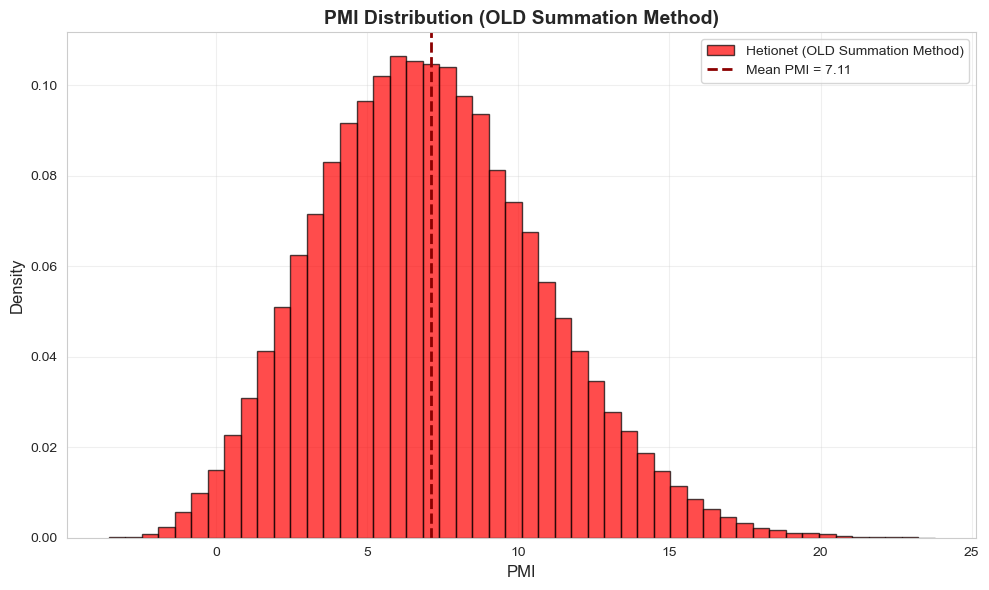

Saved PMI distribution to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/old_method_pmi_distribution.png
Mean PMI: 7.1106
Median PMI: 6.9127
Std PMI: 3.6863


In [6]:
# PMI density histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.hist(hetionet_results['pmi'], bins=50, alpha=0.7,
        label='Hetionet (OLD Summation Method)', color='red',
        density=True, edgecolor='black')

# Add mean line
mean_pmi = hetionet_results['pmi'].mean()
ax.axvline(mean_pmi, color='darkred', linestyle='--',
           linewidth=2, label=f'Mean PMI = {mean_pmi:.2f}')

ax.set_xlabel('PMI', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('PMI Distribution (OLD Summation Method)',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'old_method_pmi_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved PMI distribution to: {results_dir / 'old_method_pmi_distribution.png'}")
print(f"Mean PMI: {mean_pmi:.4f}")
print(f"Median PMI: {hetionet_results['pmi'].median():.4f}")
print(f"Std PMI: {hetionet_results['pmi'].std():.4f}")

## Degree-Stratified Scatter Plots

Visualize how node degrees affect compositional predictions.
Points colored by compound degree, pathway degree, and degree product.

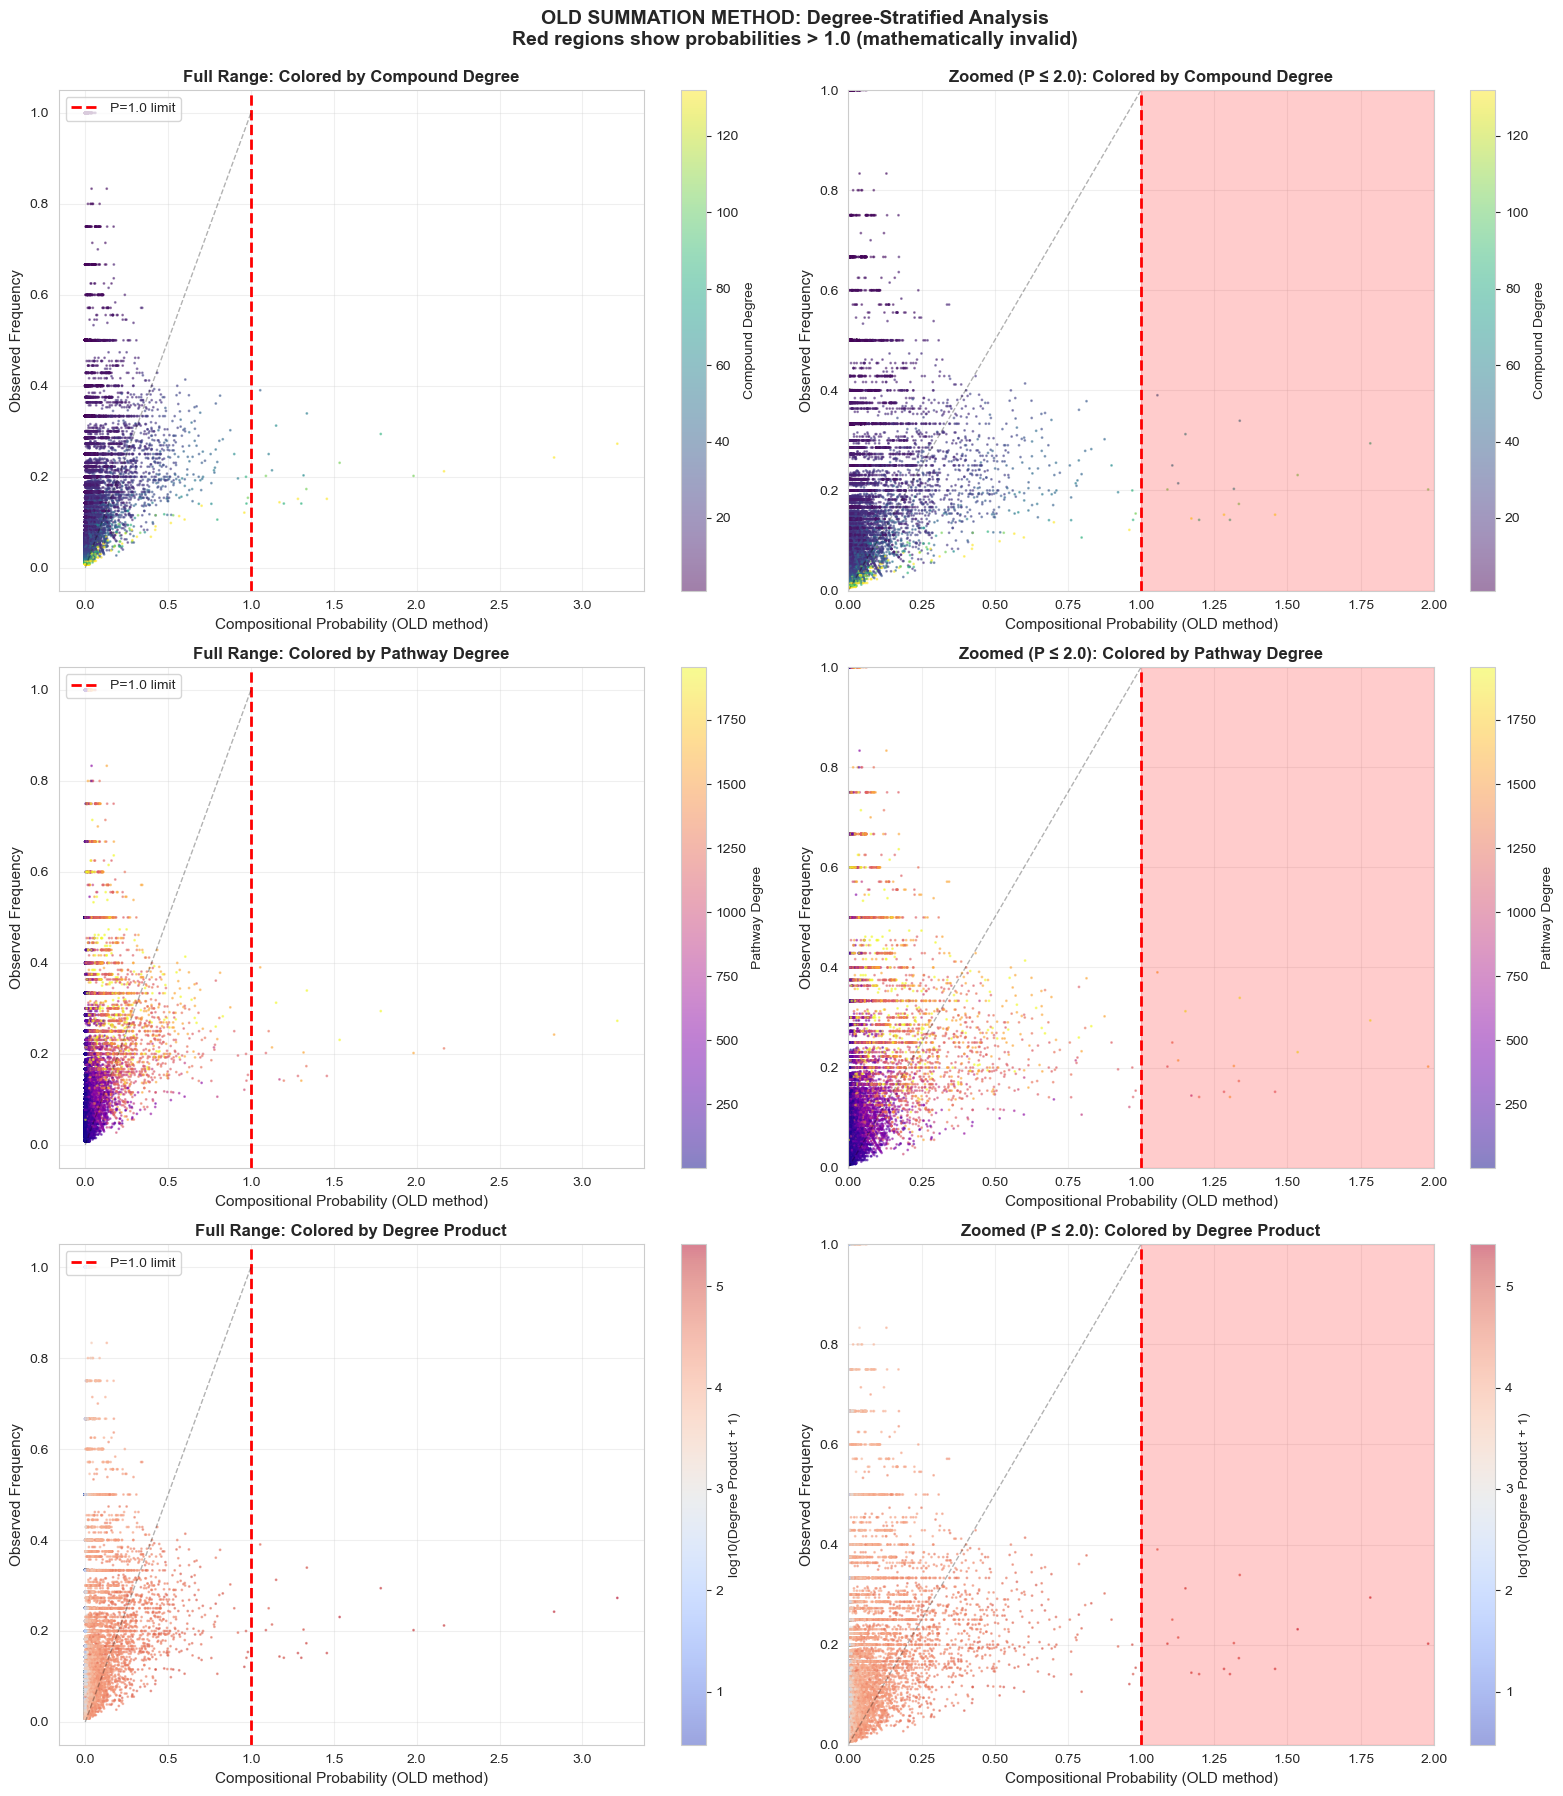


Saved scatter plots to: /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/old_method_degree_scatter_plots.png


In [7]:
# Add degree product column
hetionet_results['degree_product'] = (hetionet_results['compound_degree'] *
                                       hetionet_results['pathway_degree'])

# Create 3x2 grid of scatter plots
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Row 1: Colored by compound degree
ax = axes[0, 0]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=hetionet_results['compound_degree'],
                     cmap='viridis', alpha=0.5, s=1)
plt.colorbar(scatter, ax=ax, label='Compound Degree')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='P=1.0 limit')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Full Range: Colored by Compound Degree', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[0, 1]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=hetionet_results['compound_degree'],
                     cmap='viridis', alpha=0.5, s=1)
plt.colorbar(scatter, ax=ax, label='Compound Degree')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.0)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Zoomed (P ≤ 2.0): Colored by Compound Degree', fontsize=12, fontweight='bold')
ax.axvspan(1.0, 2.0, alpha=0.2, color='red')
ax.grid(alpha=0.3)

# Row 2: Colored by pathway degree
ax = axes[1, 0]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=hetionet_results['pathway_degree'],
                     cmap='plasma', alpha=0.5, s=1)
plt.colorbar(scatter, ax=ax, label='Pathway Degree')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='P=1.0 limit')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Full Range: Colored by Pathway Degree', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1, 1]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=hetionet_results['pathway_degree'],
                     cmap='plasma', alpha=0.5, s=1)
plt.colorbar(scatter, ax=ax, label='Pathway Degree')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.0)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Zoomed (P ≤ 2.0): Colored by Pathway Degree', fontsize=12, fontweight='bold')
ax.axvspan(1.0, 2.0, alpha=0.2, color='red')
ax.grid(alpha=0.3)

# Row 3: Colored by degree product
ax = axes[2, 0]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=np.log10(hetionet_results['degree_product'] + 1),
                     cmap='coolwarm', alpha=0.5, s=1)
cbar = plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='P=1.0 limit')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Full Range: Colored by Degree Product', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[2, 1]
scatter = ax.scatter(hetionet_results['compositional_prob'],
                     hetionet_results['observed_freq'],
                     c=np.log10(hetionet_results['degree_product'] + 1),
                     cmap='coolwarm', alpha=0.5, s=1)
cbar = plt.colorbar(scatter, ax=ax, label='log10(Degree Product + 1)')
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.0)
ax.set_xlabel('Compositional Probability (OLD method)', fontsize=11)
ax.set_ylabel('Observed Frequency', fontsize=11)
ax.set_title('Zoomed (P ≤ 2.0): Colored by Degree Product', fontsize=12, fontweight='bold')
ax.axvspan(1.0, 2.0, alpha=0.2, color='red')
ax.grid(alpha=0.3)

plt.suptitle('OLD SUMMATION METHOD: Degree-Stratified Analysis\nRed regions show probabilities > 1.0 (mathematically invalid)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(results_dir / 'old_method_degree_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved scatter plots to: {results_dir / 'old_method_degree_scatter_plots.png'}")

## Save Results

In [8]:
# Save results with OLD method suffix
hetionet_results.to_csv(results_dir / f'metapath_{metapath_name}_hetionet_OLD_SUMMATION.csv',
                        index=False)

print(f"Results saved to:")
print(f"  {results_dir / f'metapath_{metapath_name}_hetionet_OLD_SUMMATION.csv'}")
print(f"\nDataset contains {(hetionet_results['compositional_prob'] > 1.0).sum()} impossible probabilities > 1.0")
print(f"Use as comparison baseline against notebook 11.2 (corrected method)")

Results saved to:
  /Users/lucas/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/Repositories/Context-Aware-Path-Probability/results/metapath_CbGpPW_hetionet_OLD_SUMMATION.csv

Dataset contains 19 impossible probabilities > 1.0
Use as comparison baseline against notebook 11.2 (corrected method)


## Conclusions

**Mathematical Error Demonstrated:**
- OLD summation method produces probabilities > 1.0
- Violates fundamental probability axiom
- Maximum probability observed exceeds mathematical limit

**Root Cause:**
- Formula: `P = Σ P(edge1) × P(edge2)` treats pathways as additive
- No upper bound constraint

**Degree Dependencies:**
- Scatter plots show which degree ranges produce largest errors
- High-degree nodes contribute most to probability violations

**Solution:**
See notebook 11.2 for corrected Option A probabilistic combination method.